<span style="color:blue"> Changes in this version - use cohort data without ICD duplicate removal for sequence frequence check. </span>

In [1]:
import pandas as pd
import numpy as np

### 1. Building the sequences 

Event sequences are built upon the statistically significantly associated disease pairs identified using the DCN methods. We will limit the length of the sequence to 1-4 events.

In [2]:
#load the data file that contains the names of the significantly associated disease pairs
df1=pd.read_excel('pancreatic_sig_pairs_010226.xlsx')

In [3]:
#drop gastric_cancer from list
df1=df1[df1['to_disease']!='pancreatic_cancer']

In [4]:
#generate 2-event, 3-events and 4-events sequences
import networkx as nx
from collections import defaultdict

# Build a directed graph
G = nx.DiGraph()
for _, row in df1.iterrows():
    G.add_edge(row["from_disease"], row["to_disease"])

def generate_sequences(G, max_len=4):
    sequences_by_length = defaultdict(list)
    
    def dfs(path):
        if 2 <= len(path) <= max_len:
            sequences_by_length[len(path)].append(path[:])
        if len(path) < max_len:
            last = path[-1]
            for neighbor in G.successors(last):
                if neighbor not in path:  # prevent cycles
                    dfs(path + [neighbor])
    
    for node in G.nodes():
        dfs([node])
    
    return sequences_by_length

# Generate sequences grouped by length
sequences_by_length = generate_sequences(G, max_len=4)

# Convert to readable dict with counts
result = {
    f"{k}-event": {
        "count": len(v),
        "sequences": ["-".join(seq) for seq in v]
    }
    for k, v in sequences_by_length.items()
}


### 2. Check the frequencies of these sequences in the pancreatic_cancer cohort

In [5]:
#load the gastric cancer cohort data
df2=pd.read_csv('pancreatic_cancer_dcn_3l_v2.csv', low_memory=False)

In [6]:
df2.head()

,Whio_MemberId,event,ServiceDate,Age_dx,Sex,Encounter_type
0,WHIO1000492,H25,2023-10-11,72.0,M,Outpatient
1,WHIO1000492,H52,2020-10-27,69.0,M,Outpatient
2,WHIO1000492,pancreatic_cancer,2024-03-09,73.0,M,Inpatient
3,WHIO1001631,D73,2023-09-01,77.0,F,Outpatient
4,WHIO1001631,E03,2023-08-28,77.0,F,Outpatient


In [7]:
# Sort by person and date
df2 = df2.sort_values(["Whio_MemberId", "ServiceDate"])

# Example sequences from df1
sequences = result
# Function to check if a sequence exists in a list of events
def has_subsequence(events, seq):
    seq = seq.split("-")
    i = 0
    for e in events:
        if e == seq[i]:
            i += 1
            if i == len(seq):
                return True
    return False

# Build results table
rows = []
for category, v in sequences.items():
    for seq in v["sequences"]:
        count = (
            df2.groupby("Whio_MemberId")["event"]
            .apply(lambda ev: has_subsequence(ev.tolist(), seq))
            .sum()
        )
        rows.append([category, seq, count])

result_table = pd.DataFrame(rows, columns=["Category", "Sequence", "Frequency"])


In [8]:
pancreatic_seq_freq=result_table.sort_values("Frequency",ascending=False)

In [9]:
pancreatic_seq_freq.head()

,Category,Sequence,Frequency
245,2-event,M25-M79,1357
246,2-event,M25-M54,1279
210,2-event,M54-M79,1219
238,2-event,G89-M54,1124
239,2-event,G89-M25,1114


In [10]:
pancreatic_seq_freq.shape

(2552, 3)

### 3. Check the sequence frequencies in the non-pancreatic cohort

In [11]:
#load the non-gastric cancer cohort data
df3=pd.read_csv('non_pancreatic_cancer_dcn_3l_v2.csv')

In [12]:
df3=df3.sort_values(["Whio_MemberId", "ServiceDate"])
# Build results table
rows = []
for category, v in sequences.items():
    for seq in v["sequences"]:
        count = (
            df3.groupby("Whio_MemberId")["event"]
            .apply(lambda ev: has_subsequence(ev.tolist(), seq))
            .sum()
        )
        rows.append([category, seq, count])

non_pancreatic_seq_freq = pd.DataFrame(rows, columns=["Category", "Sequence", "Frequency"])


In [13]:
non_pancreatic_seq_freq=non_pancreatic_seq_freq.sort_values('Frequency',ascending=False)

### 4. Check if the frequencies differ significantly between the cohort

In [14]:
from scipy.stats import chi2_contingency, fisher_exact

# Merge on sequence
merged = pancreatic_seq_freq.merge(non_pancreatic_seq_freq, on=["Category","Sequence"], suffixes=("_pancreatic","_non_pancreatic"))

# Run tests
results = []
for _, row in merged.iterrows():
    a = row["Frequency_pancreatic"]
    b = row["Frequency_non_pancreatic"]
    
    # Build 2x2 contingency: [ [count in A, count not in A], [count in B, count not in B] ]
    contingency = [[a, sum(pancreatic_seq_freq["Frequency"]) - a],
                   [b, sum(non_pancreatic_seq_freq["Frequency"]) - b]]
    
    # Convert to numpy array and add correction for zeros
    contingency = np.array(contingency, dtype=float)
    contingency[contingency == 0] = 0.5  # add correction only to zeros
    
    # Use Fisher's exact for small counts, otherwise chi-square
    if a < 5 or b < 5:
        _, p = fisher_exact(contingency)
    else:
        chi2, p, _, _ = chi2_contingency(contingency)
    
    results.append([row["Category"], row["Sequence"], a, b, p])

# Build results table
stats_table = pd.DataFrame(results, columns=["Category","Sequence","Freq_pancreatic","Freq_non_pancreatic","p_value"])

In [15]:
#keep the ones with p-value <0.05
# filtered_seqs=stats_table[stats_table['p_value']<0.05]
filtered_seqs=stats_table[stats_table['p_value']<0.0001]

In [16]:
filtered_seqs.shape

(762, 5)

In [17]:
posi_seq=filtered_seqs[filtered_seqs['Freq_pancreatic']>filtered_seqs['Freq_non_pancreatic']]
print(f'There are {len(posi_seq)} positive sequences.')

There are 383 positive sequences.


In [18]:
positive_seq=posi_seq['Sequence'].unique()

In [19]:
#high frequency sequences (50 for pancreatic_cohort)
high_freq=filtered_seqs[filtered_seqs['Freq_pancreatic']>100]
len(high_freq)

200

In [20]:
high_posi_seq=high_freq[high_freq['Freq_pancreatic']>high_freq['Freq_non_pancreatic']]
print(f'There are {len(high_posi_seq)} high frequency positive sequences.')

There are 70 high frequency positive sequences.


In [21]:
# filtered_seqs[filtered_seqs['Freq_gastric']>filtered_seqs['Freq_non_gastric']]

In [22]:
filtered_seqs.to_csv('sig_seqs_012726.csv',index=False)

### 5. Create columns with sequence names, if a patient has that sequence, it will be labeled as 1, also creating a columns of the starting date of the sequence ; if that patient doesn't have that sequence, it's labeled as 0, the starting date is set to None

#### 5.1. Prepare the pancreatic cancer cohort

In [23]:
df=df2[['Whio_MemberId', 'event', 'ServiceDate']]
df['ServiceDate']=pd.to_datetime(df['ServiceDate'])
# sequences = filtered_seqs['Sequence'].unique()
sequences = high_freq['Sequence'].unique()
# Helper function: check subsequence and return start and end dates if found
def subsequence_start(events, dates, subseq):
    subseq = subseq.split("-")  # e.g. "a-b" -> ["a", "b"]
    m = len(subseq)
    i = 0
    start_date = None
    end_date = None

    for j, ev in enumerate(events):
        if ev == subseq[i]:
            if i == 0:
                start_date = dates[j].date()  # first match
            i += 1
            if i == m:
                end_date = dates[j].date()   # last match
                return 1, start_date, end_date

    return 0, None, None

# Aggregate events & dates per ID
df_sorted = df.sort_values(["Whio_MemberId","ServiceDate"])
agg = df_sorted.groupby("Whio_MemberId").agg({"event": list, "ServiceDate": list})

# Result dataframe
result = pd.DataFrame(index=agg.index)
## Add last event date per ID
result["last_event_date"] = agg["ServiceDate"].apply(lambda d: d[-1].date())
# Add columns for each sequence
for seq in sequences:
    result[seq] = 0
    result[seq + "_start"] = None
    
    for idx, row in agg.iterrows():
        flag, start_date,end_date = subsequence_start(row["event"], row["ServiceDate"], seq)
        result.at[idx, seq] = flag
        result.at[idx, seq + "_start"] = start_date
        result.at[idx, seq + "_end"] = end_date


C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ServiceDate']=pd.to_datetime(df['ServiceDate'])
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

...

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3690834373.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

In [24]:
pancreatic_seq_df=result.copy()

In [25]:
result.shape

(5670, 601)

In [26]:
#get demographics date
df2_demographics=df2.drop(['event', 'ServiceDate','Encounter_type'],axis=1)
df2_demographics=df2_demographics.drop_duplicates()
#keep the oldest age
idx = df2_demographics.groupby("Whio_MemberId")["Age_dx"].idxmax()
df2_dmg =df2_demographics.loc[idx].reset_index(drop=True)

In [27]:
df2_dmg.shape

(5670, 3)

In [28]:
#merge with age_dx, sex columns in df2
pancreatic_final=pd.merge(df2_dmg,pancreatic_seq_df,on='Whio_MemberId',how='left')

In [29]:
#add a column called gastric cancer
pancreatic_final['pancreatic_cancer_dx']=1

In [30]:
pancreatic_final.head()

,Whio_MemberId,Age_dx,Sex,last_event_date,M25-M79,M25-M79_start,M25-M79_end,M25-M54,M25-M54_start,M25-M54_end,...,M17-E66-E11,M17-E66-E11_start,M17-E66-E11_end,D50-K92,D50-K92_start,D50-K92_end,I48-I25-E11,I48-I25-E11_start,I48-I25-E11_end,pancreatic_cancer_dx
0,WHIO1000492,73.0,M,2024-03-09,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1
1,WHIO1001631,77.0,F,2023-09-11,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1
2,WHIO1001802,56.0,F,2021-03-08,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1
3,WHIO1001965,62.0,M,2021-01-25,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1
4,WHIO1002083,64.0,F,2019-07-23,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1


#### 6.2. Prepare the non-pancreatic cancer cohort

In [31]:
df=df3[['Whio_MemberId', 'event', 'ServiceDate']]
df['ServiceDate']=pd.to_datetime(df['ServiceDate'])

# Aggregate events & dates per ID
df_sorted = df.sort_values(["Whio_MemberId","ServiceDate"])
agg = df_sorted.groupby("Whio_MemberId").agg({"event": list, "ServiceDate": list})

# Result dataframe
result = pd.DataFrame(index=agg.index)
## Add last event date per ID
result["last_event_date"] = agg["ServiceDate"].apply(lambda d: d[-1].date())
# Add columns for each sequence
for seq in sequences:
    result[seq] = 0
    result[seq + "_start"] = None
    
    for idx, row in agg.iterrows():
        flag, start_date,end_date = subsequence_start(row["event"], row["ServiceDate"], seq)
        result.at[idx, seq] = flag
        result.at[idx, seq + "_start"] = start_date
        result.at[idx, seq + "_end"] = end_date

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ServiceDate']=pd.to_datetime(df['ServiceDate'])
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

...

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq] = 0
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[seq + "_start"] = None
C:\Users\yxing\AppData\Local\Temp\ipykernel_19604\3472784516.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

In [32]:
non_pancreatic_seq_df=result.copy()

In [33]:
#get demographics data
df3_demographics=df3.drop(['event', 'ServiceDate','Encounter_type'],axis=1)
df3_demographics=df3_demographics.drop_duplicates()

In [34]:
df3_demographics.shape

(11319, 3)

In [35]:
#merge with age_dx, sex columns in df2
non_pancreatic_final=pd.merge(df3_demographics,non_pancreatic_seq_df,on='Whio_MemberId',how='left')

In [36]:
#add a column 'gastric_cancer_dx'
non_pancreatic_final['pancreatic_cancer_dx']=0

#### 5.3. Combine the two dataset row-wise

In [37]:
#rename age for both columns to be consistent
pancreatic_final=pancreatic_final.rename(columns={'Age_dx':'Age'})
non_pancreatic_final=non_pancreatic_final.rename(columns={'Age_last_dx':'Age'})

In [38]:
#merge the two datasets
pancreatic_seq_analysis=pd.concat([pancreatic_final,non_pancreatic_final],ignore_index=True)
pancreatic_seq_analysis.shape

(16989, 605)

In [39]:
pancreatic_seq_analysis.head()

,Whio_MemberId,Age,Sex,last_event_date,M25-M79,M25-M79_start,M25-M79_end,M25-M54,M25-M54_start,M25-M54_end,...,M17-E66-E11,M17-E66-E11_start,M17-E66-E11_end,D50-K92,D50-K92_start,D50-K92_end,I48-I25-E11,I48-I25-E11_start,I48-I25-E11_end,pancreatic_cancer_dx
0,WHIO1000492,73.0,M,2024-03-09,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1
1,WHIO1001631,77.0,F,2023-09-11,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1
2,WHIO1001802,56.0,F,2021-03-08,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1
3,WHIO1001965,62.0,M,2021-01-25,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1
4,WHIO1002083,64.0,F,2019-07-23,0,None,None,0,None,None,...,0,None,None,0,None,None,0,None,None,1


In [40]:
pancreatic_seq_analysis.to_csv('pancreatic_seq_analysis_data_012726.csv')

### 6. Analysis

In [41]:
df_analysis=pancreatic_seq_analysis.copy()

In [42]:
#drop all the sequence starting dates columns
df_analysis=df_analysis.loc[:,~df_analysis.columns.str.endswith('_start')]

In [43]:
#drop all the sequence ending dates columns
df_analysis=df_analysis.loc[:,~df_analysis.columns.str.endswith('_end')]

In [44]:
#convert sex to 1-M and 0-F
df_analysis['Sex']=df_analysis['Sex'].map({"M":1,"F":0})

In [45]:
df_analysis.shape

(16989, 205)

In [46]:
df_analysis['pancreatic_cancer_dx'].value_counts()

pancreatic_cancer_dx
0    11319
1     5670
Name: count, dtype: int64

In [47]:
df_analysis.sample(5)

,Whio_MemberId,Age,Sex,last_event_date,M25-M79,M25-M54,M54-M79,G89-M54,G89-M25,G89-M79,...,I50-E87-E11,K31-J98,K29-K85,M17-M19-M25-M54,N18-I50-E87,M51-M48-M25-M54,M17-E66-E11,D50-K92,I48-I25-E11,pancreatic_cancer_dx
13800,WHIO4258873,73.0,0,2025-04-29,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14209,WHIO4430776,68.0,0,2025-05-13,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7366,WHIO1690153,68.0,1,2025-05-28,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
14065,WHIO4370245,87.0,0,2022-05-18,1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
333,WHIO1293169,55.0,1,2018-01-04,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


#### 6.1 Univariate logistic regression

In [48]:
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
import statsmodels.api as sm
# Your original code works fine for significance screening
df_lr = df_analysis.copy()
y_col = "pancreatic_cancer_dx"
X_cols = [c for c in df_lr.columns if c not in ('pancreatic_cancer_dx','Age','Sex')]
results = []

for col in X_cols:
    X = df_lr[[col]+['Age','Sex']].copy()
    X = sm.add_constant(X)
    y = df_lr[y_col]
    try:
        model = sm.Logit(y, X).fit(disp=0)

        # Focus on what you need: variable name and p-value
        summary = {
            "variable": col,
            "p_value": model.pvalues[col],
            "coef": model.params[col]
        }
        results.append(summary)
    except:
        print(f"Could not fit model for {col}")

univariate_results = pd.DataFrame(results)

# Find significant variables (p < 0.05)
significant_vars = univariate_results[univariate_results['p_value'] < 0.0001]
# print(f"Found {len(significant_vars)} significant variables")
# print(significant_vars.sort_values('p_value'))

Could not fit model for Whio_MemberId
Could not fit model for last_event_date


In [49]:
significant_vars.to_csv("sig_univariate_012726.csv")

In [50]:
len(significant_vars)

165

In [51]:
significant_vars.head()

,variable,p_value,coef
0,M25-M79,2.983519e-14,-0.286025
2,M54-M79,2.883770e-18,-0.337947
5,G89-M79,8.344085e-06,-0.188352
6,K21-K86,4.591113e-184,1.890169
7,K76-K86,1.702548e-152,1.754631


In [52]:
#number of sig-var sequences in the positive list
count = significant_vars['variable'].isin(positive_seq).sum()
count

70

#### 6.2. Predictive modeling

In [53]:
#only use sequences that are statistically significant in the univariate analysis
seq_var=significant_vars['variable'].unique()
cols_to_select = ['Age', 'Sex','pancreatic_cancer_dx'] + [col for col in seq_var if col in df_lr.columns]

In [54]:
df_pred=df_lr[cols_to_select]

In [55]:
X=df_pred.drop(['pancreatic_cancer_dx'],axis=1)
y=df_pred['pancreatic_cancer_dx']

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
# # check variable colinearity
# correlation_matrix = X.corr()
# filtered_correlation = correlation_matrix.where(abs(correlation_matrix) > 0.5)
# plt.figure(figsize=(30,20))
# sns.heatmap(filtered_correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# plt.title('Correlation Matrix')
# plt.show()

In [57]:
from sklearn.model_selection import train_test_split,cross_val_score

# we will do a 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 6.3.1. Logistic regression

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      2275
           1       0.80      0.83      0.81      1123

    accuracy                           0.87      3398
   macro avg       0.86      0.86      0.86      3398
weighted avg       0.88      0.87      0.88      3398



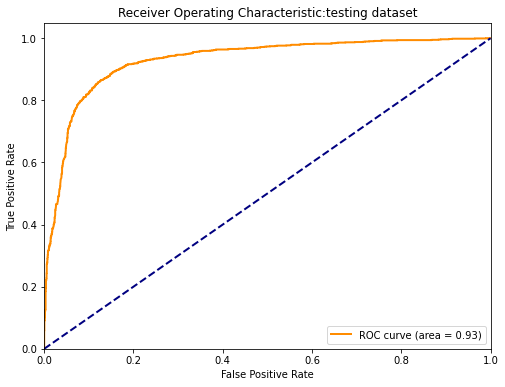

Confusion Matrix:
 [[2044  231]
 [ 194  929]]


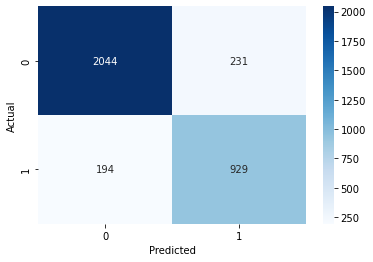

In [58]:
###Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,f1_score
LR_model = LogisticRegression(max_iter=500)
LR_model.fit(X_train, y_train) # we will train the model on the entire dataset
y_pred = LR_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
print("Classification Report: Logistic Regression")
print(classification_report(y_test, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = LR_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic:testing dataset')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

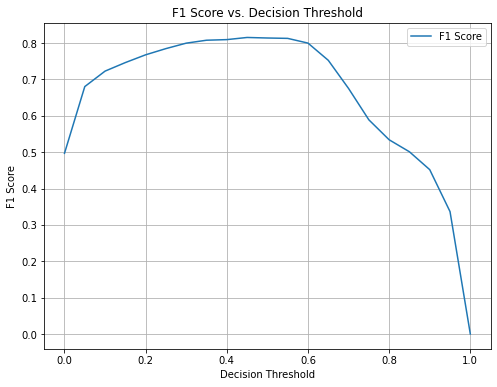

array([0.45])

In [59]:
#change the decisionthrehsold to improve model prediction 
# Define thresholds
thresholds = np.arange(0, 1.01, 0.05)

# Calculate F1 scores for each threshold
f1_scores = [f1_score(y_test, y_probs >= t) for t in thresholds]
# Find the threshold with the maximum F1 score
max_f1 = max(f1_scores)
optimal_thresholds = thresholds[np.array(f1_scores) == max_f1]
# Plot F1 score against decision threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Decision Threshold')
plt.grid(True)
plt.legend()
plt.show()
optimal_thresholds

In [60]:
y_pred_optimal = (y_probs >= 0.45).astype(int)
print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90      2275
           1       0.78      0.85      0.82      1123

    accuracy                           0.87      3398
   macro avg       0.85      0.87      0.86      3398
weighted avg       0.88      0.87      0.87      3398



Classification Report: Logistic Regression, evaluated on the training dataset
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      9044
           1       0.82      0.86      0.84      4547

    accuracy                           0.89     13591
   macro avg       0.87      0.88      0.88     13591
weighted avg       0.89      0.89      0.89     13591



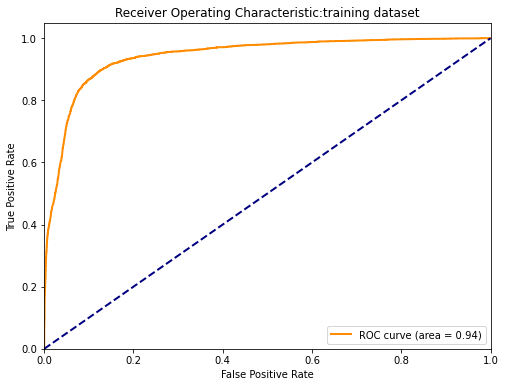

In [61]:
#troubleshooting, find out reason for poort model performance
#evaluate model on the training dataset
y_pred = LR_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: Logistic Regression, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = LR_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic:training dataset')
plt.legend(loc="lower right")
plt.show()

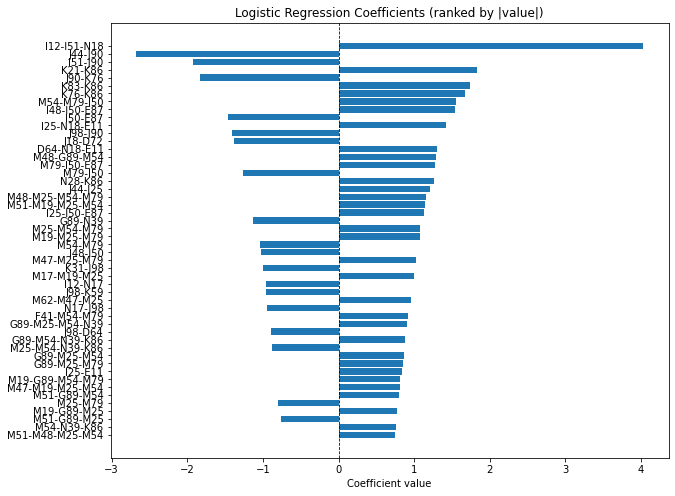

In [62]:
# Get coefficients
coef = LR_model.coef_[0]
features = X.columns

# Put into DataFrame for easy sorting
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": coef,
    "abs_coef": np.abs(coef)
})

# Sort by absolute value
coef_df = coef_df.sort_values("abs_coef", ascending=True)

# Take top 20 by absolute value
top_coef = coef_df.nlargest(50, "abs_coef").sort_values("abs_coef", ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10,8))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Logistic Regression Coefficients (ranked by |value|)")
plt.xlabel("Coefficient value")
plt.show()

In [63]:
top_coef

,feature,coefficient,abs_coef
164,M51-M48-M25-M54,0.742056,0.742056
51,M54-N39-K86,0.760795,0.760795
85,M51-G89-M25,-0.760844,0.760844
44,M19-G89-M25,0.773940,0.773940
2,M25-M79,-0.798405,0.798405
65,M51-G89-M54,0.799304,0.799304
146,M47-M19-M25-M54,0.807281,0.807281
145,M19-G89-M54-M79,0.812575,0.812575
21,I25-E11,0.843754,0.843754
12,G89-M25-M79,0.856355,0.856355


Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      2275
           1       0.76      0.83      0.79      1123

    accuracy                           0.86      3398
   macro avg       0.84      0.85      0.84      3398
weighted avg       0.86      0.86      0.86      3398



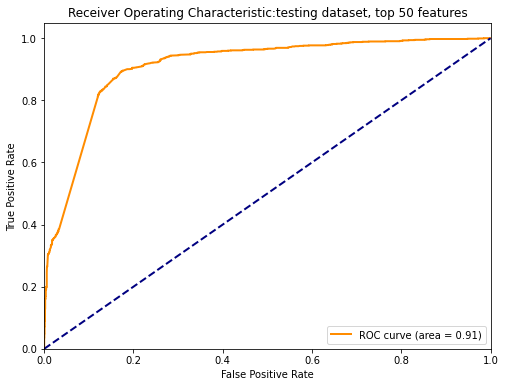

Confusion Matrix:
 [[1981  294]
 [ 189  934]]


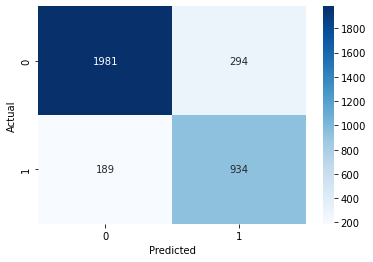

In [64]:
top_features=top_coef["feature"].tolist()
LR_top = LogisticRegression(max_iter=500)
LR_top.fit(X_train[top_features], y_train) # we will train the model on the entire dataset
y_pred = LR_top.predict(X_test[top_features])
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
print("Classification Report: Logistic Regression")
print(classification_report(y_test, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = LR_top.predict_proba(X_test[top_features])[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic:testing dataset, top 50 features')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [65]:
LR_top50=top_features

#### 6.3.2. Random forest

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      2275
           1       0.84      0.79      0.81      1123

    accuracy                           0.88      3398
   macro avg       0.87      0.86      0.86      3398
weighted avg       0.88      0.88      0.88      3398



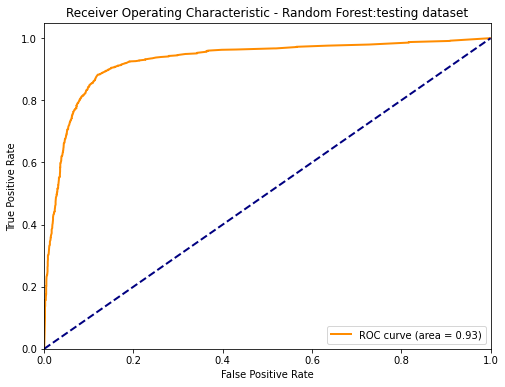

Confusion Matrix:
 [[2109  166]
 [ 241  882]]


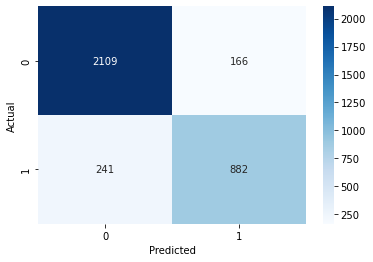

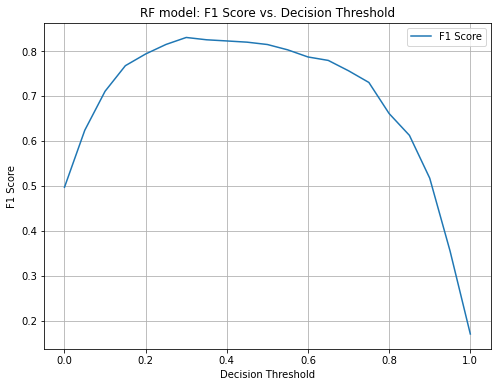

array([0.3])

In [66]:
## Random forest model
from sklearn.ensemble import RandomForestClassifier
# Train Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred=rf_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
# Predict probabilities
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Random Forest:testing dataset')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#change the decisionthrehsold to improve model prediction 
# Define thresholds
thresholds = np.arange(0, 1.01, 0.05)

# Calculate F1 scores for each threshold
f1_scores = [f1_score(y_test, y_probs >= t) for t in thresholds]
# Find the threshold with the maximum F1 score
max_f1 = max(f1_scores)
optimal_thresholds = thresholds[np.array(f1_scores) == max_f1]
# Plot F1 score against decision threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score')
plt.title('RF model: F1 Score vs. Decision Threshold')
plt.grid(True)
plt.legend()
plt.show()
optimal_thresholds

In [67]:
y_pred_optimal = (y_probs >= 0.3).astype(int)
print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      2275
           1       0.78      0.88      0.83      1123

    accuracy                           0.88      3398
   macro avg       0.86      0.88      0.87      3398
weighted avg       0.89      0.88      0.88      3398



Classification Report: Random forest, evaluated on the training dataset
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      9044
           1       0.94      0.99      0.97      4547

    accuracy                           0.98     13591
   macro avg       0.97      0.98      0.97     13591
weighted avg       0.98      0.98      0.98     13591



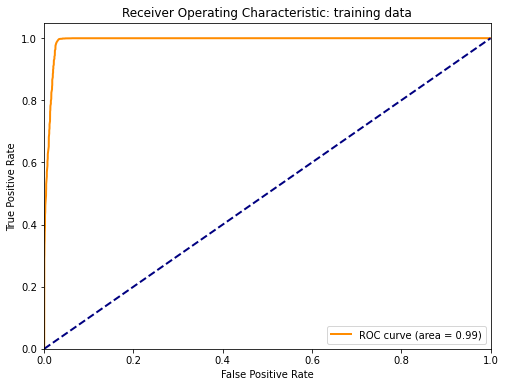

In [68]:
#troubleshooting, find out reason for poort model performance
#evaluate model on the training dataset
y_pred = rf_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: Random forest, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = rf_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic: training data')
plt.legend(loc="lower right")
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2275
           1       0.92      0.96      0.94      1123

    accuracy                           0.96      3398
   macro avg       0.95      0.96      0.96      3398
weighted avg       0.96      0.96      0.96      3398



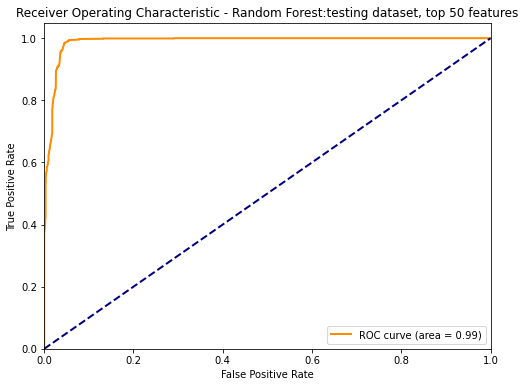

Confusion Matrix:
 [[2183   92]
 [  44 1079]]


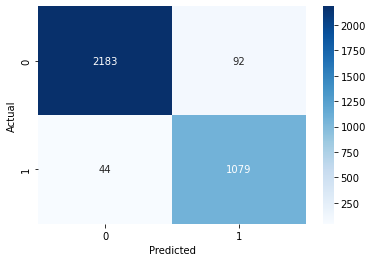

In [69]:
# Get feature importances
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Select top 20 features
top_features = importances.nlargest(50).index
# positive_seq=['K44-K22',
#            'K20-K29-K22','K44-K22-K31','K29-K22-K31','I51-I25-I50-E87']
rf_top_features = top_features.tolist()

# Refit model using only those top features
rf_top = RandomForestClassifier(n_estimators=10, random_state=42)
rf_top.fit(X[rf_top_features], y)

y_pred=rf_top.predict(X_test[rf_top_features])
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
# Predict probabilities
y_probs = rf_top.predict_proba(X_test[rf_top_features])[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Random Forest:testing dataset, top 50 features')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


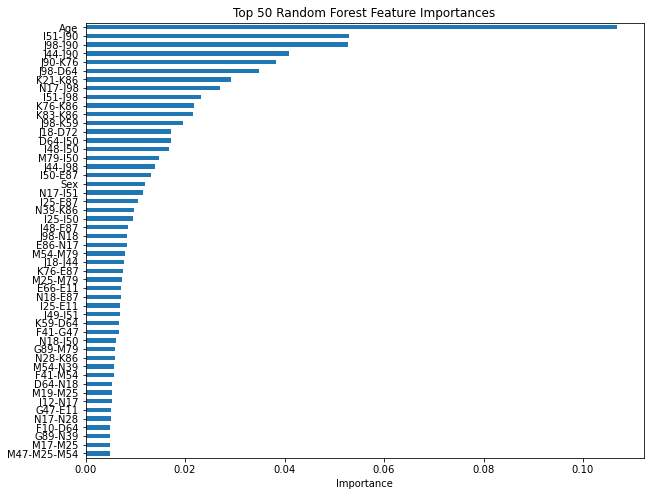

In [70]:
# Get feature importances (by default, "weight")
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Select top 20 features
top_features = importances.nlargest(50)
# Plot horizontal bar chart
plt.figure(figsize=(10,8))
top_features.sort_values().plot(kind='barh')
plt.title("Top 50 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

Classification Report: Random forest, evaluated on the training dataset
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      9044
           1       0.92      0.97      0.94      4547

    accuracy                           0.96     13591
   macro avg       0.95      0.96      0.96     13591
weighted avg       0.96      0.96      0.96     13591



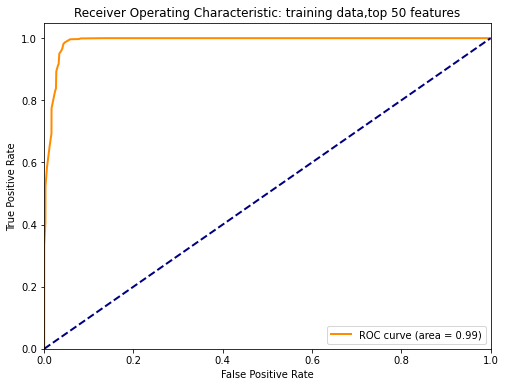

Confusion Matrix:
 [[8679  365]
 [ 156 4391]]


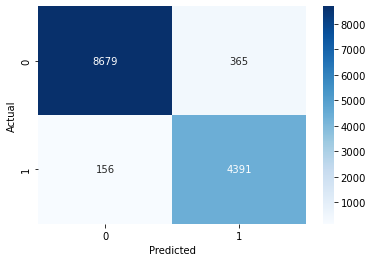

In [71]:
#troubleshooting, find out reason for poort model performance
#evaluate model on the training dataset
y_pred = rf_top.predict(X_train[rf_top_features])
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: Random forest, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = rf_top.predict_proba(X_train[rf_top_features])[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic: training data,top 50 features')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [72]:
RF_top50=rf_top_features

#### 6.3.3 XGBoost

Accuracy: 0.8881695114773396
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      2275
           1       0.82      0.85      0.83      1123

    accuracy                           0.89      3398
   macro avg       0.87      0.88      0.87      3398
weighted avg       0.89      0.89      0.89      3398



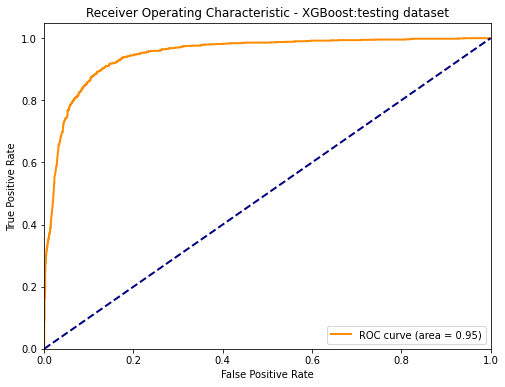

Confusion Matrix:
 [[2065  210]
 [ 170  953]]


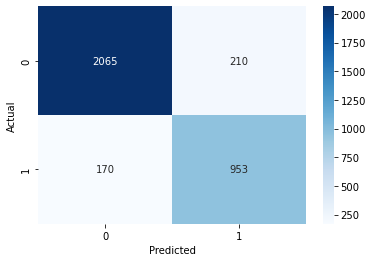

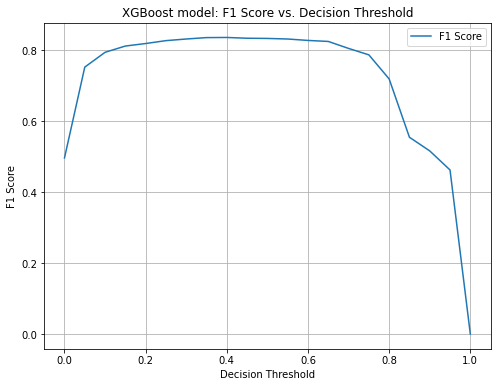

array([0.4])

In [73]:
import xgboost as xgb
# Train XGBoost classifier
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))

# Predict probabilities
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#change the decisionthrehsold to improve model prediction 
# Define thresholds
thresholds = np.arange(0, 1.01, 0.05)


# Calculate F1 scores for each threshold
f1_scores = [f1_score(y_test, y_probs >= t) for t in thresholds]
# Find the threshold with the maximum F1 score
max_f1 = max(f1_scores)
optimal_thresholds = thresholds[np.array(f1_scores) == max_f1]
# Plot F1 score against decision threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score')
plt.title('XGBoost model: F1 Score vs. Decision Threshold')
plt.grid(True)
plt.legend()
plt.show()
optimal_thresholds

Classification Report: XGBoosting, evaluated on the training dataset
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      9044
           1       0.89      0.93      0.91      4547

    accuracy                           0.94     13591
   macro avg       0.93      0.94      0.93     13591
weighted avg       0.94      0.94      0.94     13591



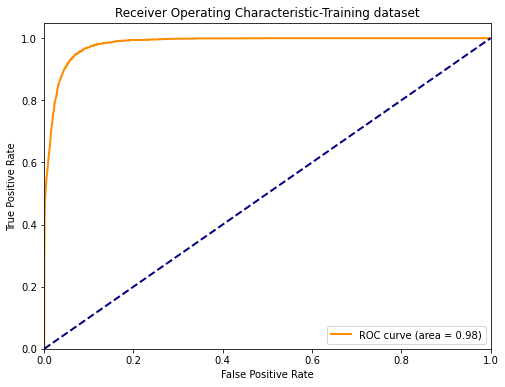

In [74]:
#trouble shooting, find out reason for poort model performance
#evaluate model on the training dataset
y_pred = xgb_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred, zero_division=0)
print("Classification Report: XGBoosting, evaluated on the training dataset")
print(classification_report(y_train, y_pred, zero_division=0))
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
y_probs = xgb_model.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic-Training dataset')
plt.legend(loc="lower right")
plt.show()

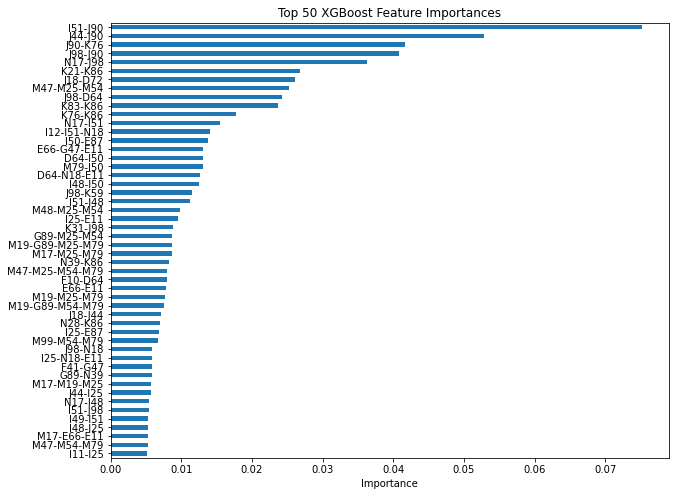

In [75]:
# Get feature importances (by default, "weight")
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)

# Select top 20 features
top_features = importances.nlargest(50)

# Plot horizontal bar chart
plt.figure(figsize=(10,8))
top_features.sort_values().plot(kind='barh')
plt.title("Top 50 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.show()

In [76]:
#model optimization

xgb_clf = xgb.XGBClassifier(
    max_depth=5, 
    learning_rate=0.05,
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    early_stopping_rounds=50,
    verbose=True
)


[0]	validation_0-auc:0.81973
[1]	validation_0-auc:0.84180
[2]	validation_0-auc:0.85996
[3]	validation_0-auc:0.86153
[4]	validation_0-auc:0.87590
[5]	validation_0-auc:0.87641
[6]	validation_0-auc:0.87642
[7]	validation_0-auc:0.87642
[8]	validation_0-auc:0.88285
[9]	validation_0-auc:0.88796
[10]	validation_0-auc:0.88814
[11]	validation_0-auc:0.89474
[12]	validation_0-auc:0.89524
[13]	validation_0-auc:0.89834
[14]	validation_0-auc:0.89879
[15]	validation_0-auc:0.89956
[16]	validation_0-auc:0.90268
[17]	validation_0-auc:0.90421
[18]	validation_0-auc:0.90735
[19]	validation_0-auc:0.90789
[20]	validation_0-auc:0.90847
[21]	validation_0-auc:0.90989
[22]	validation_0-auc:0.91025
[23]	validation_0-auc:0.90993
[24]	validation_0-auc:0.91093
[25]	validation_0-auc:0.91238
[26]	validation_0-auc:0.91234
[27]	validation_0-auc:0.91244
[28]	validation_0-auc:0.91257
[29]	validation_0-auc:0.91276
[30]	validation_0-auc:0.91319
[31]	validation_0-auc:0.91321
[32]	validation_0-auc:0.91328
[33]	validation_0-au

[268]	validation_0-auc:0.94632
[269]	validation_0-auc:0.94633
[270]	validation_0-auc:0.94647
[271]	validation_0-auc:0.94650
[272]	validation_0-auc:0.94646
[273]	validation_0-auc:0.94637
[274]	validation_0-auc:0.94637
[275]	validation_0-auc:0.94651
[276]	validation_0-auc:0.94647
[277]	validation_0-auc:0.94652
[278]	validation_0-auc:0.94650
[279]	validation_0-auc:0.94653
[280]	validation_0-auc:0.94658
[281]	validation_0-auc:0.94653
[282]	validation_0-auc:0.94654
[283]	validation_0-auc:0.94656
[284]	validation_0-auc:0.94661
[285]	validation_0-auc:0.94661
[286]	validation_0-auc:0.94658
[287]	validation_0-auc:0.94659
[288]	validation_0-auc:0.94665
[289]	validation_0-auc:0.94668
[290]	validation_0-auc:0.94675
[291]	validation_0-auc:0.94666
[292]	validation_0-auc:0.94666
[293]	validation_0-auc:0.94671
[294]	validation_0-auc:0.94675
[295]	validation_0-auc:0.94676
[296]	validation_0-auc:0.94680
[297]	validation_0-auc:0.94686
[298]	validation_0-auc:0.94697
[299]	validation_0-auc:0.94705
[300]	va

[533]	validation_0-auc:0.94898
[534]	validation_0-auc:0.94897
[535]	validation_0-auc:0.94898
[536]	validation_0-auc:0.94896
[537]	validation_0-auc:0.94897
[538]	validation_0-auc:0.94900
[539]	validation_0-auc:0.94899
[540]	validation_0-auc:0.94897
[541]	validation_0-auc:0.94894


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

Accuracy: 0.8917010005885815
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      2275
           1       0.82      0.85      0.84      1123

    accuracy                           0.89      3398
   macro avg       0.88      0.88      0.88      3398
weighted avg       0.89      0.89      0.89      3398



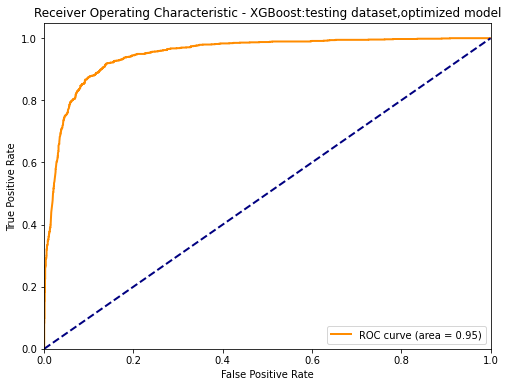

Confusion Matrix:
 [[2071  204]
 [ 164  959]]


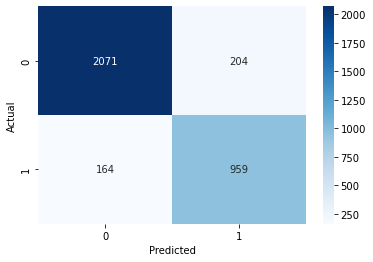

In [77]:
y_pred = xgb_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))


# Predict probabilities
y_probs = xgb_clf.predict_proba(X_test)[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset,optimized model')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Accuracy: 0.8696291936433196
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      2275
           1       0.77      0.86      0.81      1123

    accuracy                           0.87      3398
   macro avg       0.85      0.87      0.86      3398
weighted avg       0.88      0.87      0.87      3398



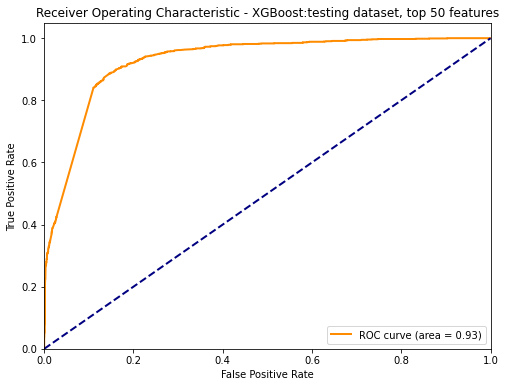

Confusion Matrix:
 [[1991  284]
 [ 159  964]]


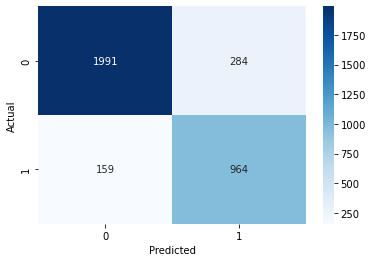

In [78]:
top_50 = importances.nlargest(50).index
xgb_top_features=top_50.tolist()
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train[xgb_top_features], y_train)

y_pred = xgb_model.predict(X_test[xgb_top_features])
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))


# Predict probabilities
y_probs = xgb_model.predict_proba(X_test[xgb_top_features])[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset, top 50 features')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [79]:
XGB_top50=xgb_top_features

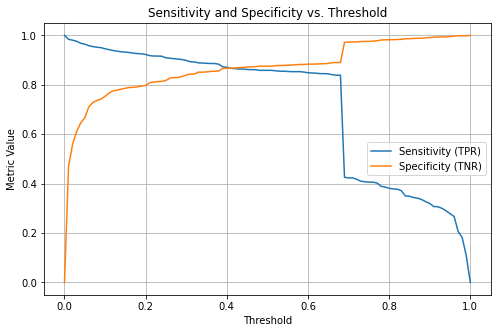

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assume you already have:
# y_true  → actual binary outcomes (0 or 1)
# y_pred_prob → predicted probabilities from XGBoost (model.predict_proba(...)[...,1])

thresholds = np.linspace(0, 1, 101)
sensitivity = []
specificity = []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificity.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, sensitivity, label='Sensitivity (TPR)')
plt.plot(thresholds, specificity, label='Specificity (TNR)')
plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.title('Sensitivity and Specificity vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()


In [81]:
df_comp=pd.concat([X_test[xgb_top_features],y_test],axis=1)
df_comp['y_pred']=y_pred

In [82]:
df_comp.shape

(3398, 52)

In [83]:
#model optimization

xgb_clf = xgb.XGBClassifier(
    max_depth=5, 
    learning_rate=0.05,
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    early_stopping_rounds=50,
    verbose=True
)


[0]	validation_0-auc:0.81973
[1]	validation_0-auc:0.84180
[2]	validation_0-auc:0.85996
[3]	validation_0-auc:0.86153
[4]	validation_0-auc:0.87590
[5]	validation_0-auc:0.87641
[6]	validation_0-auc:0.87642
[7]	validation_0-auc:0.87642
[8]	validation_0-auc:0.88285
[9]	validation_0-auc:0.88796
[10]	validation_0-auc:0.88814
[11]	validation_0-auc:0.89474
[12]	validation_0-auc:0.89524
[13]	validation_0-auc:0.89834
[14]	validation_0-auc:0.89879
[15]	validation_0-auc:0.89956
[16]	validation_0-auc:0.90268
[17]	validation_0-auc:0.90421
[18]	validation_0-auc:0.90735
[19]	validation_0-auc:0.90789
[20]	validation_0-auc:0.90847
[21]	validation_0-auc:0.90989
[22]	validation_0-auc:0.91025
[23]	validation_0-auc:0.90993
[24]	validation_0-auc:0.91093
[25]	validation_0-auc:0.91238
[26]	validation_0-auc:0.91234
[27]	validation_0-auc:0.91244
[28]	validation_0-auc:0.91257
[29]	validation_0-auc:0.91276
[30]	validation_0-auc:0.91319
[31]	validation_0-auc:0.91321
[32]	validation_0-auc:0.91328
[33]	validation_0-au

[268]	validation_0-auc:0.94632
[269]	validation_0-auc:0.94633
[270]	validation_0-auc:0.94647
[271]	validation_0-auc:0.94650
[272]	validation_0-auc:0.94646
[273]	validation_0-auc:0.94637
[274]	validation_0-auc:0.94637
[275]	validation_0-auc:0.94651
[276]	validation_0-auc:0.94647
[277]	validation_0-auc:0.94652
[278]	validation_0-auc:0.94650
[279]	validation_0-auc:0.94653
[280]	validation_0-auc:0.94658
[281]	validation_0-auc:0.94653
[282]	validation_0-auc:0.94654
[283]	validation_0-auc:0.94656
[284]	validation_0-auc:0.94661
[285]	validation_0-auc:0.94661
[286]	validation_0-auc:0.94658
[287]	validation_0-auc:0.94659
[288]	validation_0-auc:0.94665
[289]	validation_0-auc:0.94668
[290]	validation_0-auc:0.94675
[291]	validation_0-auc:0.94666
[292]	validation_0-auc:0.94666
[293]	validation_0-auc:0.94671
[294]	validation_0-auc:0.94675
[295]	validation_0-auc:0.94676
[296]	validation_0-auc:0.94680
[297]	validation_0-auc:0.94686
[298]	validation_0-auc:0.94697
[299]	validation_0-auc:0.94705
[300]	va

[533]	validation_0-auc:0.94898
[534]	validation_0-auc:0.94897
[535]	validation_0-auc:0.94898
[536]	validation_0-auc:0.94896
[537]	validation_0-auc:0.94897
[538]	validation_0-auc:0.94900
[539]	validation_0-auc:0.94899
[540]	validation_0-auc:0.94897
[541]	validation_0-auc:0.94894


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

Accuracy: 0.8917010005885815
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      2275
           1       0.82      0.85      0.84      1123

    accuracy                           0.89      3398
   macro avg       0.88      0.88      0.88      3398
weighted avg       0.89      0.89      0.89      3398



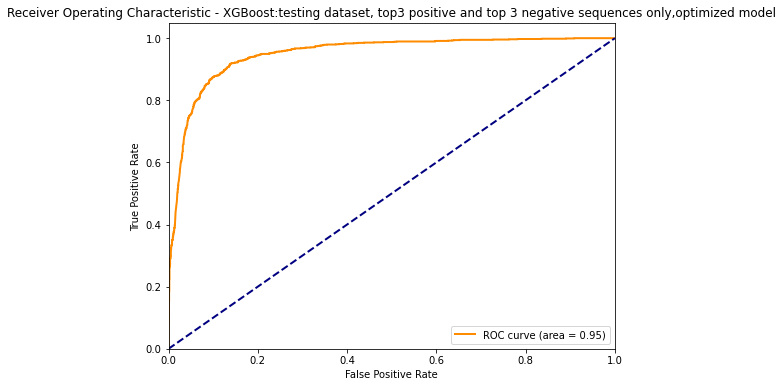

Confusion Matrix:
 [[2071  204]
 [ 164  959]]


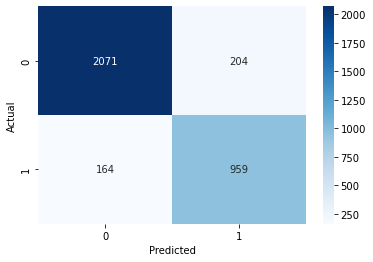

In [84]:
y_pred = xgb_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))


# Predict probabilities
y_probs = xgb_clf.predict_proba(X_test)[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset, top3 positive and top 3 negative sequences only,optimized model')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [85]:
#number of sig-var sequences in the positive list
RF_pos_count = set(RF_top50) & set(positive_seq)
len(RF_pos_count)

7

In [86]:
RF_pos_count

{'E66-E11',
 'K21-K86',
 'K76-K86',
 'K83-K86',
 'M47-M25-M54',
 'N28-K86',
 'N39-K86'}

In [87]:
#number of sig-var sequences in the positive list
XGBoost_pos_count = set(XGB_top50) & set(positive_seq)
len(XGBoost_pos_count)

21

In [88]:
XGBoost_pos_count

{'E66-E11',
 'E66-G47-E11',
 'G89-M25-M54',
 'I12-I51-N18',
 'I25-N18-E11',
 'K21-K86',
 'K76-K86',
 'K83-K86',
 'M17-E66-E11',
 'M17-M19-M25',
 'M17-M25-M79',
 'M19-G89-M25-M79',
 'M19-G89-M54-M79',
 'M19-M25-M79',
 'M47-M25-M54',
 'M47-M25-M54-M79',
 'M47-M54-M79',
 'M48-M25-M54',
 'M99-M54-M79',
 'N28-K86',
 'N39-K86'}

In [89]:
rf_xgb=set(RF_pos_count) & set(XGBoost_pos_count)
rf_xgb

{'E66-E11',
 'K21-K86',
 'K76-K86',
 'K83-K86',
 'M47-M25-M54',
 'N28-K86',
 'N39-K86'}

### 8. Timing of last sequence-full model

In [90]:
var_list=significant_vars['variable'].unique().tolist()+['last_event_date','pancreatic_cancer_dx','Whio_MemberId']

In [91]:
#subset the pancreaticc_seq_ananlysis dataframe. taking all columns related to those in the significant_vars list
sig_cols=[col for col in pancreatic_seq_analysis.columns if any(col.startswith(name) for name in var_list)]
df_last_timing=pancreatic_seq_analysis[sig_cols]

In [92]:
#get all _end columns
end_cols=[c for c in df_last_timing.columns if '_end' in c.lower()]
date_cols=end_cols+['last_event_date']
#comvert all date columsn to datetime
df_last_timing[date_cols] = df_last_timing[date_cols].apply(pd.to_datetime, errors='coerce')

#compute the lastest event end dates across those columns
df_last_timing['last_seq_date']=df_last_timing[end_cols].max(axis=1)
#compute time between last sequence and last event date
df_last_timing['last_seq_to_last_event']=(df_last_timing['last_event_date']-df_last_timing['last_seq_date']).dt.days

In [93]:
#get the second last event-sequence date based on end date
df_last_timing['last_seq_to_last_event'].describe()

count    14749.000000
mean       256.669062
std        429.147194
min          0.000000
25%          7.000000
50%         60.000000
75%        311.000000
max       3017.000000
Name: last_seq_to_last_event, dtype: float64

In [94]:
df_last_timing['last_seq_to_last_event'].median()

60.0

<Axes: xlabel='last_seq_to_last_event', ylabel='Count'>

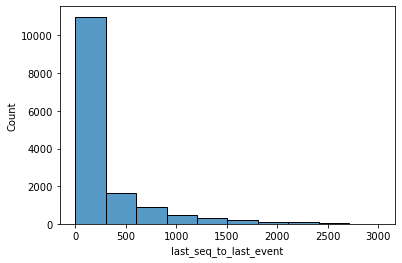

In [95]:
import seaborn as sns
sns.histplot(df_last_timing['last_seq_to_last_event'],bins=10)

In [96]:
df_last_timing[df_last_timing['last_seq_to_last_event']<=30].shape

(6139, 521)

In [97]:
df_last_timing.shape

(16989, 521)

In [98]:
pancreatic_only=df_last_timing[df_last_timing['pancreatic_cancer_dx']==1]
pancreatic_only['last_seq_to_last_event'].describe()

count    3918.00000
mean      170.02246
std       335.83691
min         1.00000
25%         8.00000
50%        29.00000
75%       173.00000
max      2769.00000
Name: last_seq_to_last_event, dtype: float64

<Axes: xlabel='last_seq_to_last_event', ylabel='Count'>

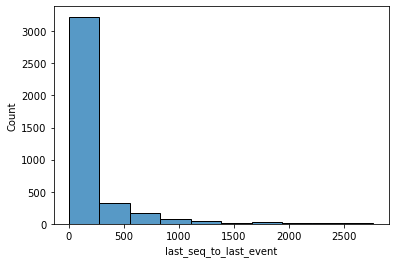

In [99]:
sns.histplot(pancreatic_only['last_seq_to_last_event'],bins=10)

### 9. Timing of last sequence-top 50 features model

In [100]:
LR_top50_var_list=LR_top50+['last_event_date','pancreatic_cancer_dx','Whio_MemberId']
RF_top50_var_list=RF_top50+['last_event_date','pancreatic_cancer_dx','Whio_MemberId']
XGB_top50_var_list=XGB_top50+['last_event_date','pancreatic_cancer_dx','Whio_MemberId']

In [101]:
#subset the pancreaticc_seq_ananlysis dataframe. taking all columns related to those in the significant_vars list
LR_sig_cols=[col for col in pancreatic_seq_analysis.columns if any(col.startswith(name) for name in LR_top50_var_list)]
df_last_timing=pancreatic_seq_analysis[LR_sig_cols]
#get all _end columns
end_cols=[c for c in df_last_timing.columns if '_end' in c.lower()]
date_cols=end_cols+['last_event_date']
#comvert all date columsn to datetime
df_last_timing[date_cols] = df_last_timing[date_cols].apply(pd.to_datetime, errors='coerce')

#compute the lastest event end dates across those columns
df_last_timing['last_seq_date']=df_last_timing[end_cols].max(axis=1)
#compute time between last sequence and last event date
df_last_timing['last_seq_to_last_event']=(df_last_timing['last_event_date']-df_last_timing['last_seq_date']).dt.days

In [102]:
df_last_timing['last_seq_to_last_event'].describe()

count    13550.000000
mean       388.782583
std        551.317291
min          0.000000
25%         15.000000
50%        131.000000
75%        553.750000
max       3068.000000
Name: last_seq_to_last_event, dtype: float64

In [103]:
pancreatic_only=df_last_timing[df_last_timing['pancreatic_cancer_dx']==1]
pancreatic_only['last_seq_to_last_event'].describe()

count    3296.000000
mean      219.557342
std       388.913777
min         1.000000
25%         9.000000
50%        39.000000
75%       247.250000
max      2700.000000
Name: last_seq_to_last_event, dtype: float64

In [104]:
#subset the pancreaticc_seq_ananlysis dataframe. taking all columns related to those in the significant_vars list
RF_sig_cols=[col for col in pancreatic_seq_analysis.columns if any(col.startswith(name) for name in RF_top50_var_list)]
df_last_timing=pancreatic_seq_analysis[RF_sig_cols]
#get all _end columns
end_cols=[c for c in df_last_timing.columns if '_end' in c.lower()]
date_cols=end_cols+['last_event_date']
#comvert all date columsn to datetime
df_last_timing[date_cols] = df_last_timing[date_cols].apply(pd.to_datetime, errors='coerce')

#compute the lastest event end dates across those columns
df_last_timing['last_seq_date']=df_last_timing[end_cols].max(axis=1)
#compute time between last sequence and last event date
df_last_timing['last_seq_to_last_event']=(df_last_timing['last_event_date']-df_last_timing['last_seq_date']).dt.days

In [105]:
df_last_timing['last_seq_to_last_event'].describe()

count    14470.000000
mean       309.915342
std        477.370475
min          0.000000
25%         10.000000
50%         87.000000
75%        407.000000
max       3017.000000
Name: last_seq_to_last_event, dtype: float64

In [106]:
pancreatic_only=df_last_timing[df_last_timing['pancreatic_cancer_dx']==1]
pancreatic_only['last_seq_to_last_event'].describe()

count    3712.000000
mean      204.365571
std       373.012584
min         1.000000
25%         9.000000
50%        37.000000
75%       226.000000
max      2553.000000
Name: last_seq_to_last_event, dtype: float64

In [107]:
#subset the pancreaticc_seq_ananlysis dataframe. taking all columns related to those in the significant_vars list
XGB_sig_cols=[col for col in pancreatic_seq_analysis.columns if any(col.startswith(name) for name in XGB_top50_var_list)]
df_last_timing=pancreatic_seq_analysis[XGB_sig_cols]
#get all _end columns
end_cols=[c for c in df_last_timing.columns if '_end' in c.lower()]
date_cols=end_cols+['last_event_date']
#comvert all date columsn to datetime
df_last_timing[date_cols] = df_last_timing[date_cols].apply(pd.to_datetime, errors='coerce')

#compute the lastest event end dates across those columns
df_last_timing['last_seq_date']=df_last_timing[end_cols].max(axis=1)
#compute time between last sequence and last event date
df_last_timing['last_seq_to_last_event']=(df_last_timing['last_event_date']-df_last_timing['last_seq_date']).dt.days

In [108]:
df_last_timing['last_seq_to_last_event'].describe()

count    13661.000000
mean       337.284020
std        507.162563
min          0.000000
25%         12.000000
50%        100.000000
75%        452.000000
max       3017.000000
Name: last_seq_to_last_event, dtype: float64

In [109]:
pancreatic_only=df_last_timing[df_last_timing['pancreatic_cancer_dx']==1]
pancreatic_only['last_seq_to_last_event'].describe()

count    3327.00000
mean      202.98437
std       374.91261
min         1.00000
25%         8.00000
50%        34.00000
75%       218.00000
max      2538.00000
Name: last_seq_to_last_event, dtype: float64

### 10. Compare the top features of thre three models

In [110]:
#overlap of variables in 3 different models
top50=list(set(LR_top50).intersection(RF_top50, XGB_top50))
top50

['N17-J98',
 'K76-K86',
 'I25-E11',
 'I51-J90',
 'I50-E87',
 'N28-K86',
 'J98-J90',
 'G89-N39',
 'J44-J90',
 'J90-K76',
 'K83-K86',
 'J18-D72',
 'J98-K59',
 'M79-I50',
 'I48-I50',
 'K21-K86',
 'J98-D64']

In [111]:
top50_p=list(set(top50) & set(positive_seq))
top50_p

['N28-K86', 'K21-K86', 'K83-K86', 'K76-K86']

In [112]:
#positive sequences in the top 50 of LR models
LR_top50_p=list(set(LR_top50) & set(positive_seq))
LR_top50_p

['I25-N18-E11',
 'K76-K86',
 'M19-G89-M25',
 'M51-M48-M25-M54',
 'G89-M54-N39-K86',
 'M62-M47-M25',
 'M54-N39-K86',
 'M51-G89-M54',
 'M19-G89-M54-M79',
 'M25-M54-N39-K86',
 'M51-M19-M25-M54',
 'M17-M19-M25',
 'K83-K86',
 'G89-M25-M54',
 'M47-M19-M25-M54',
 'M47-M25-M79',
 'M48-M25-M54-M79',
 'M19-M25-M79',
 'K21-K86',
 'I12-I51-N18',
 'M48-G89-M54',
 'N28-K86']

In [113]:
#positive sequences in the top 50 of the RF models
RF_top50_p=list(set(RF_top50) & set(positive_seq))
RF_top50_p

['K76-K86',
 'N28-K86',
 'E66-E11',
 'M47-M25-M54',
 'K83-K86',
 'K21-K86',
 'N39-K86']

In [114]:
#positive sequences in the top 50 of the XGB models
XGB_top50_p=list(set(XGB_top50) & set(positive_seq))
XGB_top50_p

['I25-N18-E11',
 'K76-K86',
 'M48-M25-M54',
 'M47-M25-M54',
 'M19-G89-M54-M79',
 'E66-G47-E11',
 'K83-K86',
 'M19-G89-M25-M79',
 'M17-M19-M25',
 'M17-E66-E11',
 'M99-M54-M79',
 'G89-M25-M54',
 'N39-K86',
 'E66-E11',
 'M47-M25-M54-M79',
 'M19-M25-M79',
 'M17-M25-M79',
 'K21-K86',
 'I12-I51-N18',
 'N28-K86',
 'M47-M54-M79']

### 9. Model with positive sequence only

### 9.1. RF -positive sequence

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.93      0.83      2275
           1       0.72      0.35      0.47      1123

    accuracy                           0.74      3398
   macro avg       0.73      0.64      0.65      3398
weighted avg       0.73      0.74      0.71      3398



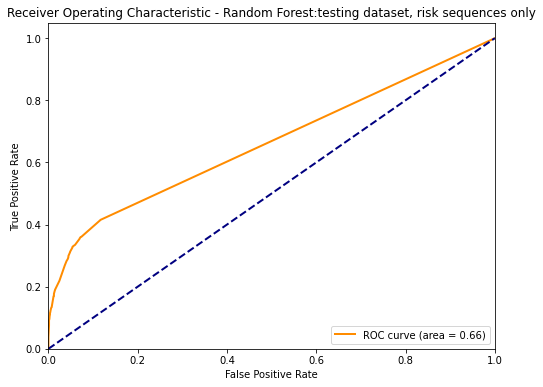

Confusion Matrix:
 [[2117  158]
 [ 726  397]]


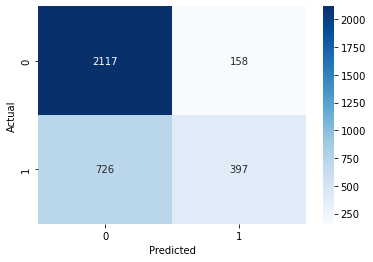

In [115]:
# Select top 20 features
# top_features = importances.nlargest(50).index
rf_top_features = RF_top50_p

# Refit model using only those top features
rf_top = RandomForestClassifier(n_estimators=10, random_state=42)
rf_top.fit(X[rf_top_features], y)

y_pred=rf_top.predict(X_test[rf_top_features])
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
# Predict probabilities
y_probs = rf_top.predict_proba(X_test[rf_top_features])[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Random Forest:testing dataset, risk sequences only')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [118]:
RF_top50_var_list=RF_top50_p+['last_event_date','pancreatic_cancer_dx','Whio_MemberId']
#subset the pancreaticc_seq_ananlysis dataframe. taking all columns related to those in the significant_vars list
RF_sig_cols=[col for col in pancreatic_seq_analysis.columns if any(col.startswith(name) for name in RF_top50_var_list)]
df_last_timing=pancreatic_seq_analysis[RF_sig_cols]
#get all _end columns
end_cols=[c for c in df_last_timing.columns if '_end' in c.lower()]
date_cols=end_cols+['last_event_date']
#comvert all date columsn to datetime
df_last_timing[date_cols] = df_last_timing[date_cols].apply(pd.to_datetime, errors='coerce')

#compute the lastest event end dates across those columns
df_last_timing['last_seq_date']=df_last_timing[end_cols].max(axis=1)
#compute time between last sequence and last event date
df_last_timing['last_seq_to_last_event']=(df_last_timing['last_event_date']-df_last_timing['last_seq_date']).dt.days

df_last_timing['last_seq_to_last_event'].describe()

count    3682.000000
mean      479.797936
std       685.254252
min         0.000000
25%        13.000000
50%       113.000000
75%       714.000000
max      3047.000000
Name: last_seq_to_last_event, dtype: float64

In [119]:

pancreatic_only=df_last_timing[df_last_timing['pancreatic_cancer_dx']==1]
pancreatic_only['last_seq_to_last_event'].describe()

count    2389.000000
mean      224.122645
std       435.847003
min         1.000000
25%         7.000000
50%        26.000000
75%       203.000000
max      2637.000000
Name: last_seq_to_last_event, dtype: float64

### 9.2 XGBoost model with risk sequences only

Accuracy: 0.7404355503237199
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.93      0.83      2275
           1       0.72      0.35      0.47      1123

    accuracy                           0.74      3398
   macro avg       0.73      0.64      0.65      3398
weighted avg       0.74      0.74      0.71      3398



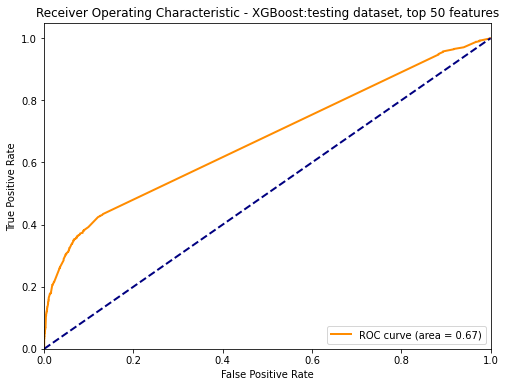

Confusion Matrix:
 [[2119  156]
 [ 726  397]]


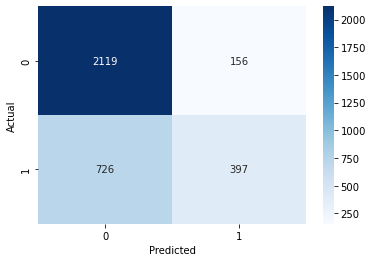

In [120]:

xgb_top_features=XGB_top50_p
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train[xgb_top_features], y_train)

y_pred = xgb_model.predict(X_test[xgb_top_features])
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))


# Predict probabilities
y_probs = xgb_model.predict_proba(X_test[xgb_top_features])[:, 1]

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - XGBoost:testing dataset, top 50 features')
plt.legend(loc="lower right")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [121]:
XGB_top50_var_list=XGB_top50_p+['last_event_date','pancreatic_cancer_dx','Whio_MemberId']
#subset the pancreaticc_seq_ananlysis dataframe. taking all columns related to those in the significant_vars list
RF_sig_cols=[col for col in pancreatic_seq_analysis.columns if any(col.startswith(name) for name in XGB_top50_var_list)]
df_last_timing=pancreatic_seq_analysis[RF_sig_cols]
#get all _end columns
end_cols=[c for c in df_last_timing.columns if '_end' in c.lower()]
date_cols=end_cols+['last_event_date']
#comvert all date columsn to datetime
df_last_timing[date_cols] = df_last_timing[date_cols].apply(pd.to_datetime, errors='coerce')

#compute the lastest event end dates across those columns
df_last_timing['last_seq_date']=df_last_timing[end_cols].max(axis=1)
#compute time between last sequence and last event date
df_last_timing['last_seq_to_last_event']=(df_last_timing['last_event_date']-df_last_timing['last_seq_date']).dt.days

df_last_timing['last_seq_to_last_event'].describe()

count    5652.000000
mean      613.577495
std       757.394730
min         0.000000
25%        24.000000
50%       274.500000
75%       974.000000
max      3047.000000
Name: last_seq_to_last_event, dtype: float64

In [122]:

pancreatic_only=df_last_timing[df_last_timing['pancreatic_cancer_dx']==1]
pancreatic_only['last_seq_to_last_event'].describe()

count    2861.000000
mean      240.032506
std       419.118611
min         1.000000
25%         9.000000
50%        40.000000
75%       283.000000
max      2765.000000
Name: last_seq_to_last_event, dtype: float64